## Estimate the number of Richardson-Lucy (RL) deconvolution iterations

One issue with iterative deconvolution algorithms is the lack of clear stopping criteria. This example demonstrates how use image quality measures (PSNR, SSIM, FSC, and DCR) to track the progress of GPU-based 3D RL deconvolution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

from cubic.cuda import CUDAManager, ascupy, asnumpy
from cubic.metrics import psnr, ssim, dcr_resolution, fsc_resolution
from cubic.preprocessing import deconv_iter_num_finder
from cubic.preprocessing.deconvolution import richardson_lucy_iter

USE_GPU = CUDAManager().num_gpus > 0
print(f"GPU available: {USE_GPU}")

### Load data and the PSF

A single 3D stack of Hoechst-stained astrocyte nuclei acquired with a Yokogawa CQ1 confocal microscope.
Theoretical 3D point spread function (PSF) was modeled using the Richards and Wolf algorithm from the PSFGenerator plugin for Fiji [1].
The image and the PSF can be [downloaded from Google Drive](../data/README.md).

The PSF is center-cropped to 30×210×210 (capturing 99.5% of energy) — RL deconvolution zero-pads it to the image size internally. The image is cropped to a 1024×1024 cell-region patch for faster processing.

In [ ]:
scale_xy = 0.1625
scale_z = 0.3
voxel_sizes = (scale_z, scale_xy, scale_xy)

image = imread("../data/astr_vpa_hoechst.tif")
psf = imread("../data/astr_vpa_hoechst_psf_na095_cropped.tif")

# Crop image to 1024x1024 cell region
y0, x0 = 1000, 1300  # cell-region anchor
image = image[:, y0 : y0 + 1024, x0 : x0 + 1024]

print(f"Image shape: {image.shape}")
print(f"PSF shape:   {psf.shape}")

# Move to GPU if available
if USE_GPU:
    image = ascupy(image)
    psf = ascupy(psf)

print(f"Device: {'GPU' if USE_GPU else 'CPU'}")

The image is cropped to $30 \times 1024 \times 1024$ from the cell region. The PSF is $30 \times 210 \times 210$ (center-cropped to 99.5% energy).

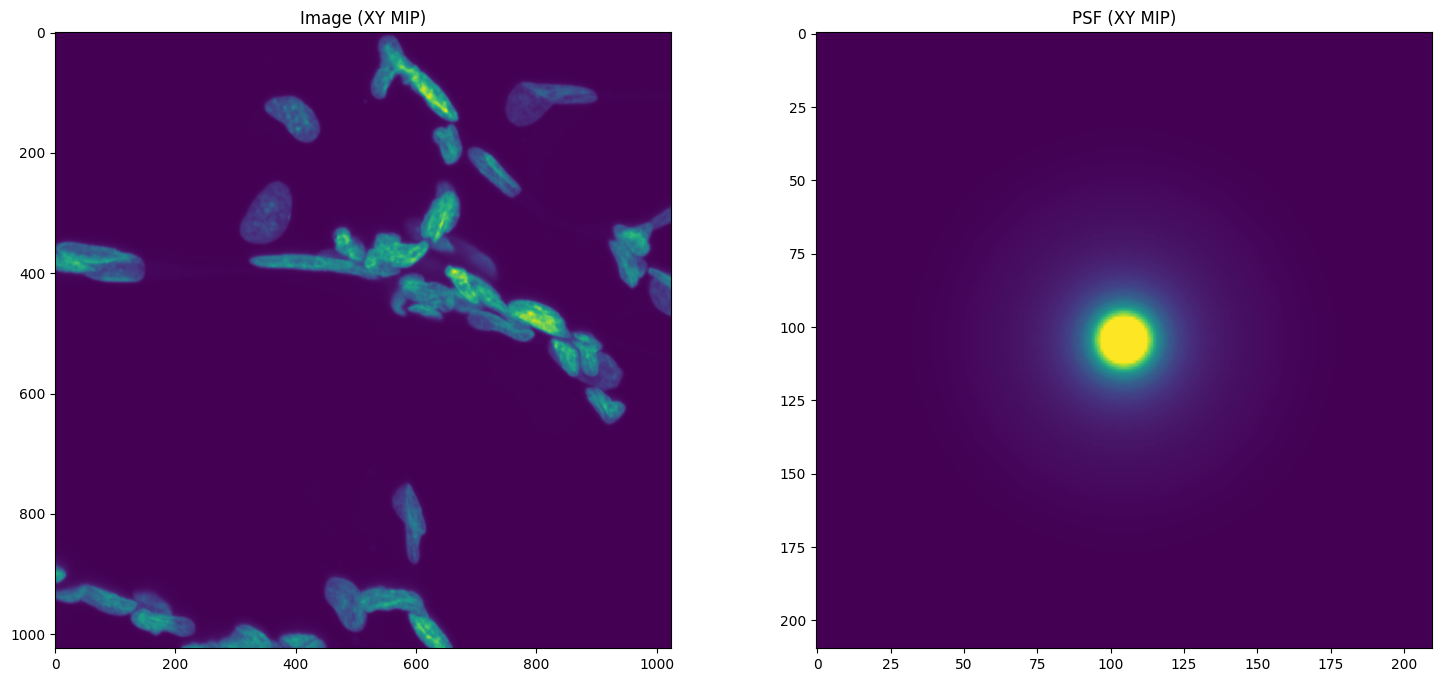

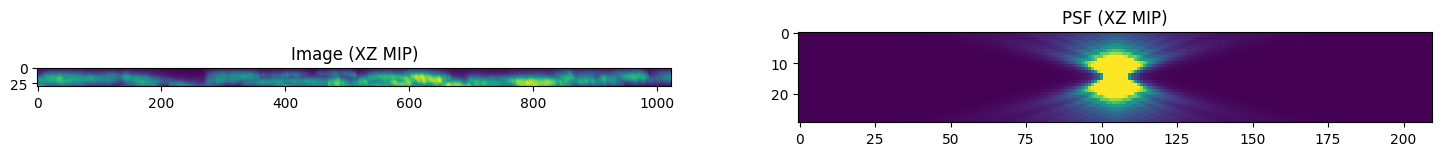

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(asnumpy(image.max(0)))
axes[0].set_title("Image (XY MIP)")
axes[1].imshow(asnumpy(psf.max(0)), vmax=0.01)
axes[1].set_title("PSF (XY MIP)")
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
axes[0].imshow(asnumpy(image.max(1)))
axes[0].set_title("Image (XZ MIP)")
axes[1].imshow(asnumpy(psf.max(1)), vmax=0.01)
axes[1].set_title("PSF (XZ MIP)")
plt.show()

### Use PSNR improvement as a metric of decon quality

Here we demonstrate how to use peak signal-to-noise ratio (PSNR) as a criteria for determining the number of RL iterations.
cubic will run RL on a GPU and at each iteration compare restored image with one from the previous iteration using psnr also calculated on GPU.
By default, images are padded in Z in 'reflect' mode on both sides up to 32 slices.

When provided threshold is reached, it returns the number of iterations and an object metric gains and intermediate images from all iterations.
Note that the RL will run for full `max_iter` iterations.

We use fast RL `xpy` implementation adapted from `tnia-python` library [2].

In [4]:
psnr_thresh_iter, psnr_resolution = deconv_iter_num_finder(
    image,
    psf,
    metric_fn=psnr,
    metric_kwargs={"scale_invariant": True},
    metric_threshold=75.0,
    max_iter=50,
    verbose=True,
    implementation="xpy",
)

Iteration 1: improvement 43.05277853
Iteration 2: improvement 48.03959936


Iteration 3: improvement 51.48286982
Iteration 4: improvement 54.12037900


Iteration 5: improvement 56.24532960
Iteration 6: improvement 58.01322521


Iteration 7: improvement 59.51901280
Iteration 8: improvement 60.82533847


Iteration 9: improvement 61.97550843
Iteration 10: improvement 63.00045015


...

Iteration 27: improvement 72.14412519
Iteration 28: improvement 72.44608671


Iteration 29: improvement 72.73372250
Iteration 30: improvement 73.15925914


Iteration 31: improvement 73.57705618
Iteration 32: improvement 73.98075371


Iteration 33: improvement 74.37101348
Iteration 34: improvement 74.74847598


Iteration 35: improvement 75.11380131

Threshold 75.0 reached at iteration 35 with improvement: 75.11380131.
Metric between original and restored images: 28.71649181.



Now we can visualize the progress according to the provided metric.

PSNR doesn't quite plateau before reaching this threshold of 80 dB, which means it can be further increased, if needed.

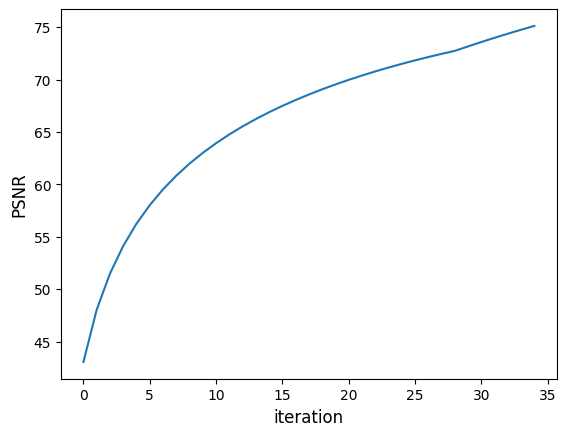

In [5]:
plt.plot([res["metric_gain"] for res in psnr_resolution[1:]])
plt.xlabel("iteration", fontsize=12)
plt.ylabel("PSNR", fontsize=12)
plt.show()

And visualize original and restored images from the iteration at threshold next to each other.

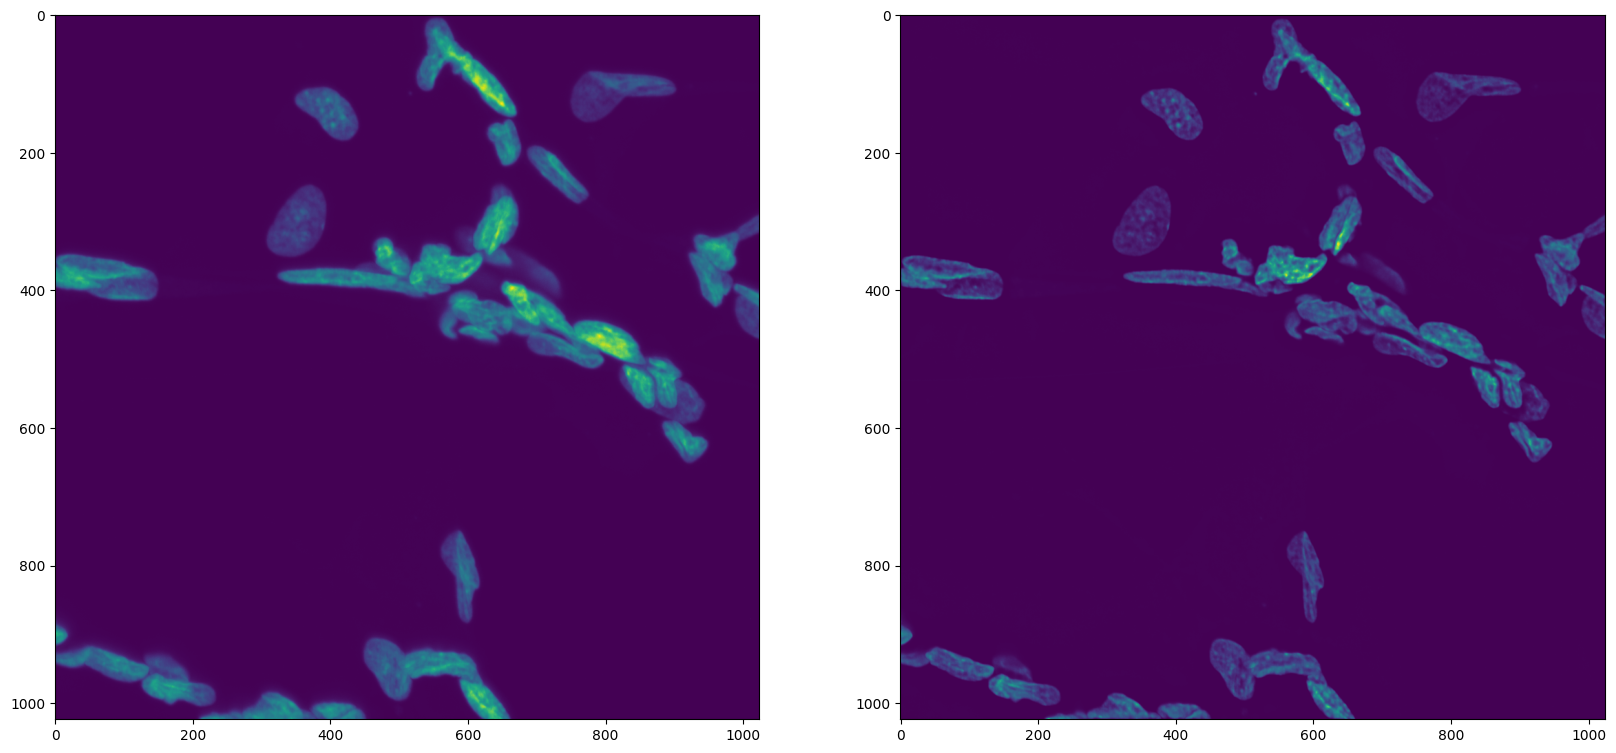

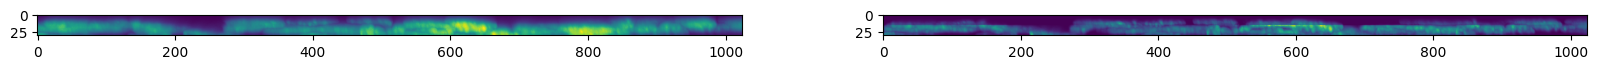

In [6]:
deconv_image = psnr_resolution[psnr_thresh_iter]["iter_image"]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(asnumpy(image.max(0)))
axes[1].imshow(asnumpy(deconv_image.max(0)))
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(asnumpy(image.max(1)))
axes[1].imshow(asnumpy(deconv_image.max(1)))
plt.show()

### Use SSIM improvement as a metric of decon quality

Now, we repeat the process using structured similarity index (SSIM) as a progress metric instead.

In [7]:
ssim_thresh_iter, ssim_resolution = deconv_iter_num_finder(
    image,
    psf,
    metric_fn=ssim,
    metric_kwargs={"scale_invariant": True},
    metric_threshold=0.99999,
    max_iter=50,
    verbose=True,
    implementation="xpy",
    noncirc=False,
)

Iteration 1: improvement 0.97788747
Iteration 2: improvement 0.99098085


Iteration 3: improvement 0.99537415
Iteration 4: improvement 0.99730583


Iteration 5: improvement 0.99829724
Iteration 6: improvement 0.99885805


Iteration 7: improvement 0.99919817


Iteration 8: improvement 0.99941578


...

Iteration 30: improvement 0.99998064
Iteration 31: improvement 0.99998257


Iteration 32: improvement 0.99998426
Iteration 33: improvement 0.99998574


Iteration 34: improvement 0.99998705
Iteration 35: improvement 0.99998820


Iteration 36: improvement 0.99998922
Iteration 37: improvement 0.99999013



Threshold 0.99999 reached at iteration 37 with improvement: 0.99999013.
Metric between original and restored images: 0.74503041.



When visualized, SSIM shows reachin a plateau even before 10 iterations. This makes sense, because SSIM measures the perceived change in structural information, while PSNR estimates an absolute error.

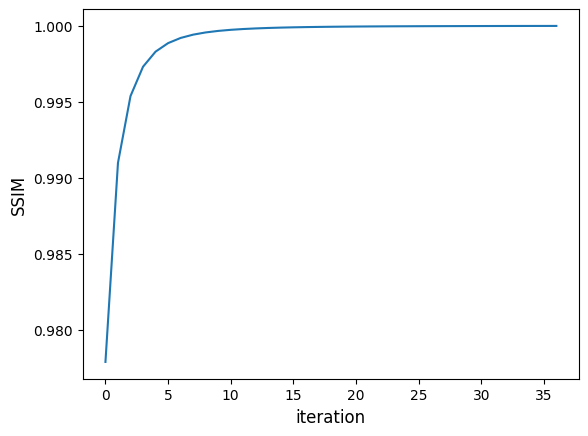

In [8]:
plt.plot([res["metric_gain"] for res in ssim_resolution[1:]])
plt.xlabel("iteration", fontsize=12)
plt.ylabel("SSIM", fontsize=12)
plt.show()

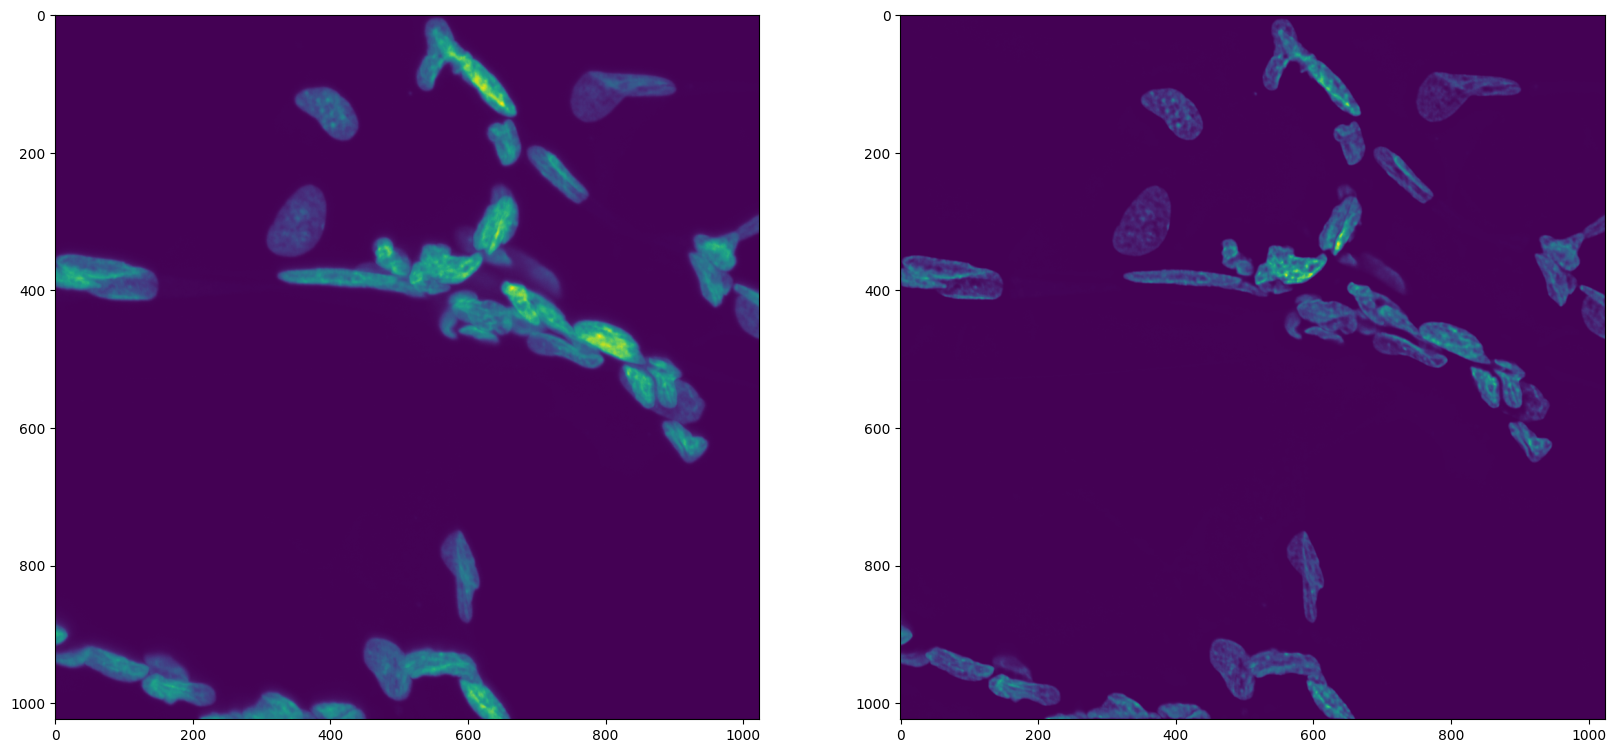

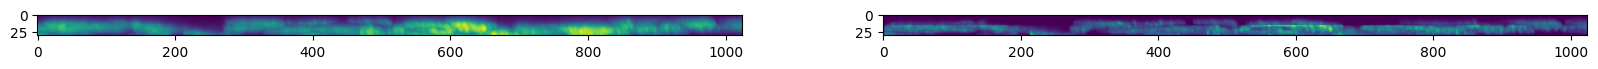

In [9]:
deconv_image = ssim_resolution[ssim_thresh_iter]["iter_image"]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(asnumpy(image.max(0)))
axes[1].imshow(asnumpy(deconv_image.max(0)))
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(asnumpy(image.max(1)))
axes[1].imshow(asnumpy(deconv_image.max(1)))
plt.show()

### Use 3D FSC-based resolution estimation as a metric of decon quality

Following Koho et al. (2019, Fig. 3), we track **absolute FSC resolution** at each RL iteration and use the derivative $\nabla d_{min}$ (rate of change in resolution per iteration) as a stopping criterion. Deconvolution stops when $|\nabla d_{min}| < \theta$, where $\theta$ is a threshold in nm/iteration.

Key parameters for 3D FSC:
- `resample_isotropic=True`: Resample to isotropic voxels (recommended for anisotropic data)
- `exclude_axis_angle`: Exclude frequencies near Z axis to avoid piezo artifacts (typical: 5-10°)
- `backend='hist'`: Use GPU-accelerated vectorized backend

In [10]:
# Track absolute FSC resolution at each iteration (Koho et al. 2019, Fig. 3b)
# Stop when |Δresolution| < metric_threshold (nm/iteration)
fsc_metric_threshold = 1.0  # nm/iteration

fsc_kwargs = dict(
    spacing=voxel_sizes,
    resample_isotropic=True,
    exclude_axis_angle=5.0,
    backend="hist",
)

# Storage for absolute resolution at each iteration
fsc_xy_resolutions = []
fsc_z_resolutions = []
_fsc_prev_avg = [None]  # mutable closure for previous average resolution


def fsc_convergence_metric(image1, image2, **kwargs):
    """Compute FSC resolution of current image and return -|Δavg(XY,Z)|.

    Following Koho et al. 2019: track absolute resolution, stop when
    the per-iteration change drops below threshold. Returns negative
    value so deconv_iter_num_finder's `metric_gain > metric_threshold`
    triggers correctly (stop when -|Δ| > -threshold, i.e. |Δ| < threshold).
    """
    # Only compute FSC of the current image (image2), ignore image1
    res = fsc_resolution(image2, **fsc_kwargs)
    xy_nm = res["xy"] * 1000
    z_nm = res["z"] * 1000
    fsc_xy_resolutions.append(xy_nm)
    fsc_z_resolutions.append(z_nm)

    avg_res = (xy_nm + z_nm) / 2.0

    if _fsc_prev_avg[0] is None:
        _fsc_prev_avg[0] = avg_res
        return -1000.0  # large negative = big change, don't stop yet

    delta = abs(avg_res - _fsc_prev_avg[0])
    _fsc_prev_avg[0] = avg_res
    return -delta  # negative; approaches 0 as convergence occurs


# Compute raw image resolution first
fsc_raw = fsc_resolution(image, **fsc_kwargs)
fsc_xy_resolutions.append(fsc_raw["xy"] * 1000)
fsc_z_resolutions.append(fsc_raw["z"] * 1000)
_fsc_prev_avg[0] = (fsc_xy_resolutions[0] + fsc_z_resolutions[0]) / 2.0
print(f"Raw: XY={fsc_xy_resolutions[0]:.1f} nm, Z={fsc_z_resolutions[0]:.1f} nm")

fsc_thresh_iter, fsc_resolution_results = deconv_iter_num_finder(
    image,
    psf,
    metric_fn=fsc_convergence_metric,
    metric_threshold=-fsc_metric_threshold,  # -1.0: stop when -|Δ| > -1.0
    max_iter=50,
    verbose=True,
    implementation="xpy",
)

print(
    f"\nFSC converged at iteration {fsc_thresh_iter} (|Δ| < {fsc_metric_threshold} nm/it)"
)
print(f"  XY: {fsc_xy_resolutions[0]:.1f} → {fsc_xy_resolutions[-1]:.1f} nm")
print(f"  Z:  {fsc_z_resolutions[0]:.1f} → {fsc_z_resolutions[-1]:.1f} nm")

Raw: XY=352.8 nm, Z=423.6 nm


Iteration 1: improvement -11.39095666
Iteration 2: improvement -77.91084182


Iteration 3: improvement -37.96161677


Iteration 4: improvement -29.31204883


Iteration 5: improvement -22.85530057


...

Iteration 35: improvement -1.16165776
Iteration 36: improvement -1.12595916


Iteration 37: improvement -1.13321517
Iteration 38: improvement -1.16632588


Iteration 39: improvement -1.02012029
Iteration 40: improvement -1.06621275


Iteration 41: improvement -0.96368968

Threshold -1.0 reached at iteration 41 with improvement: -0.96368968.
Metric between original and restored images: -0.00000000.




FSC converged at iteration 41 (|Δ| < 1.0 nm/it)
  XY: 352.8 → 240.5 nm
  Z:  423.6 → 271.5 nm


FSC-based tracking provides 3D resolution assessment, capturing improvements in both lateral (XY) and axial (Z) directions separately, following the approach of Koho et al. (2019, Fig. 3).

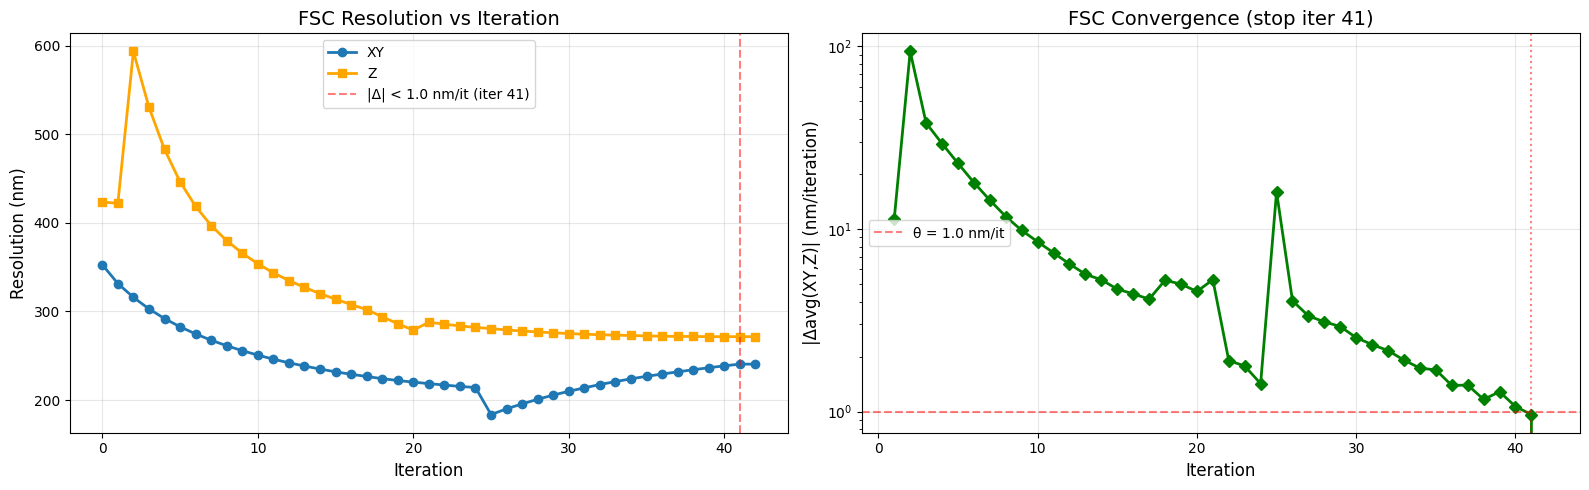

In [11]:
# Fig 3-style plots: absolute resolution and convergence
iterations = np.arange(len(fsc_xy_resolutions))
xy = np.array(fsc_xy_resolutions)
z = np.array(fsc_z_resolutions)

# Derivative: |Δavg(XY,Z)| per iteration
d_xy = np.abs(np.diff(xy))
d_z = np.abs(np.diff(z))
d_avg = (d_xy + d_z) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute resolution vs iteration
axes[0].plot(iterations, xy, "o-", label="XY", linewidth=2)
axes[0].plot(iterations, z, "s-", color="orange", label="Z", linewidth=2)
if fsc_thresh_iter > 0:
    axes[0].axvline(
        x=fsc_thresh_iter,
        color="r",
        linestyle="--",
        alpha=0.5,
        label=f"|Δ| < {fsc_metric_threshold} nm/it (iter {fsc_thresh_iter})",
    )
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Resolution (nm)", fontsize=12)
axes[0].set_title("FSC Resolution vs Iteration", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) |Δavg| convergence
axes[1].plot(iterations[1:], d_avg, "D-", color="green", linewidth=2)
axes[1].axhline(
    y=fsc_metric_threshold,
    color="r",
    linestyle="--",
    alpha=0.5,
    label=f"θ = {fsc_metric_threshold} nm/it",
)
if fsc_thresh_iter > 0:
    axes[1].axvline(x=fsc_thresh_iter, color="r", linestyle=":", alpha=0.5)
axes[1].set_xlabel("Iteration", fontsize=12)
axes[1].set_ylabel("|Δavg(XY,Z)| (nm/iteration)", fontsize=12)
axes[1].set_title(f"FSC Convergence (stop iter {fsc_thresh_iter})", fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

### Use 3D DCR-based resolution estimation as a metric of decon quality

Decorrelation Analysis (DCR) is a single-image resolution metric that doesn't require splitting the image. For 3D volumes, DCR supports full angular sectoring (similar to FSC) to provide separate XY and Z resolution estimates.

**Note on DCR iteration tracking:** While Descloux et al. (2019, Supplementary Results 5) demonstrate smooth DCR resolution tracking across RL iterations on 2D SOFI data, we observe quantized resolution jumps with our 3D confocal data. This is because DCR's `max(k_c)` selection operates over a discrete set of high-pass-filtered decorrelation curves (`num_highpass=10` by default), and the peak can only jump between these curves' maxima — producing ~10 discrete candidate resolution values per sector. The original Matlab implementation (ImDecorr) uses the same approach but was validated on dense 2D super-resolution data with higher SNR in the frequency domain. For tracking gradual deconvolution changes on sparse 3D confocal data, FSC provides smoother convergence curves (see above).

In [12]:
# Track absolute DCR resolution at each iteration
dcr_kwargs = dict(
    spacing=voxel_sizes,
    exclude_axis_angle=5.0,
    use_sectioned=True,
    num_highpass=10,
)

# Compute resolution of raw image
dcr_raw = dcr_resolution(image, **dcr_kwargs)
dcr_xy_resolutions = [dcr_raw["xy"] * 1000]  # nm
dcr_z_resolutions = [dcr_raw["z"] * 1000]
print(f"Raw: XY={dcr_xy_resolutions[0]:.1f} nm, Z={dcr_z_resolutions[0]:.1f} nm")


def dcr_observer(restored_image, iteration):
    """Compute and store absolute DCR resolution at each iteration."""
    res = dcr_resolution(restored_image, **dcr_kwargs)
    xy_nm = res["xy"] * 1000
    z_nm = res["z"] * 1000
    dcr_xy_resolutions.append(xy_nm)
    dcr_z_resolutions.append(z_nm)
    d_xy = xy_nm - dcr_xy_resolutions[-2]
    d_z = z_nm - dcr_z_resolutions[-2]
    print(
        f"Iter {iteration:2d}: XY={xy_nm:.1f} nm (Δ={d_xy:+.1f}), Z={z_nm:.1f} nm (Δ={d_z:+.1f})"
    )


richardson_lucy_iter(
    image, psf, n_iter=50, implementation="xp", observer_fn=dcr_observer
);

Raw: XY=919.3 nm, Z=973.8 nm


Iter  1: XY=919.3 nm (Δ=+0.0), Z=973.8 nm (Δ=+0.0)


Iter  2: XY=1005.5 nm (Δ=+86.2), Z=973.8 nm (Δ=+0.0)


Iter  3: XY=1037.9 nm (Δ=+32.4), Z=973.8 nm (Δ=+0.0)


Iter  4: XY=1037.9 nm (Δ=+0.0), Z=973.8 nm (Δ=+0.0)


...

Iter 46: XY=804.4 nm (Δ=+0.0), Z=873.5 nm (Δ=+0.0)


Iter 47: XY=784.8 nm (Δ=-19.6), Z=873.5 nm (Δ=+0.0)


Iter 48: XY=784.8 nm (Δ=+0.0), Z=873.5 nm (Δ=+0.0)


Iter 49: XY=784.8 nm (Δ=+0.0), Z=873.5 nm (Δ=+0.0)


Iter 50: XY=784.8 nm (Δ=+0.0), Z=873.5 nm (Δ=+0.0)


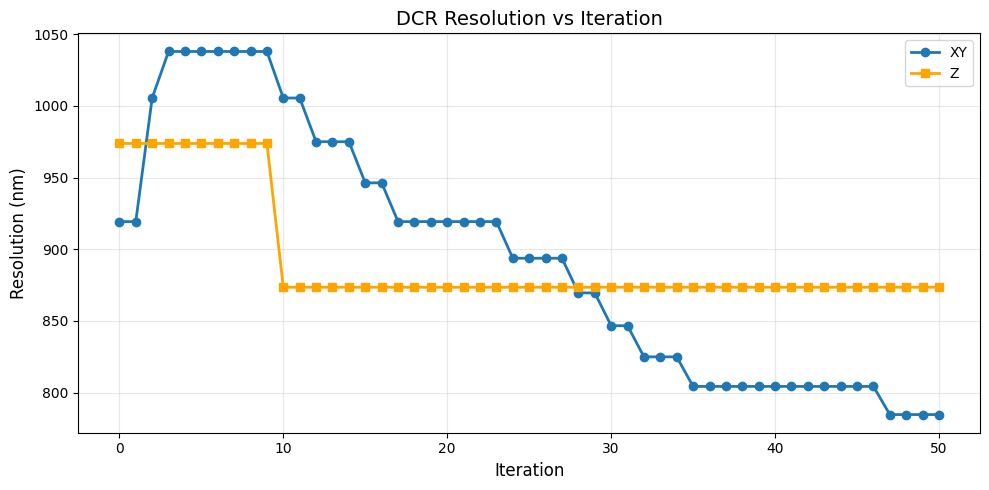

DCR resolution (50 iterations):
  XY: 919.3 → 784.8 nm (Δ=-134.5 nm)
  Z:  973.8 → 873.5 nm (Δ=-100.2 nm)


In [13]:
# DCR resolution across iterations
dcr_iters = np.arange(len(dcr_xy_resolutions))
dcr_xy = np.array(dcr_xy_resolutions)
dcr_z = np.array(dcr_z_resolutions)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dcr_iters, dcr_xy, "o-", label="XY", linewidth=2)
ax.plot(dcr_iters, dcr_z, "s-", color="orange", label="Z", linewidth=2)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Resolution (nm)", fontsize=12)
ax.set_title("DCR Resolution vs Iteration", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"DCR resolution (50 iterations):")
print(
    f"  XY: {dcr_xy[0]:.1f} → {dcr_xy[-1]:.1f} nm (Δ={dcr_xy[-1] - dcr_xy[0]:+.1f} nm)"
)
print(f"  Z:  {dcr_z[0]:.1f} → {dcr_z[-1]:.1f} nm (Δ={dcr_z[-1] - dcr_z[0]:+.1f} nm)")

### Comparison: 3D FSC vs 3D DCR

Both FSC and DCR now provide full 3D resolution analysis with angular sectoring:

- **FSC**: Requires checkerboard splitting, analyzes correlation between two half-images
- **DCR**: Single-image analysis, no splitting artifacts

Both methods return separate XY and Z resolution estimates, allowing you to track how deconvolution improves lateral vs axial resolution differently.

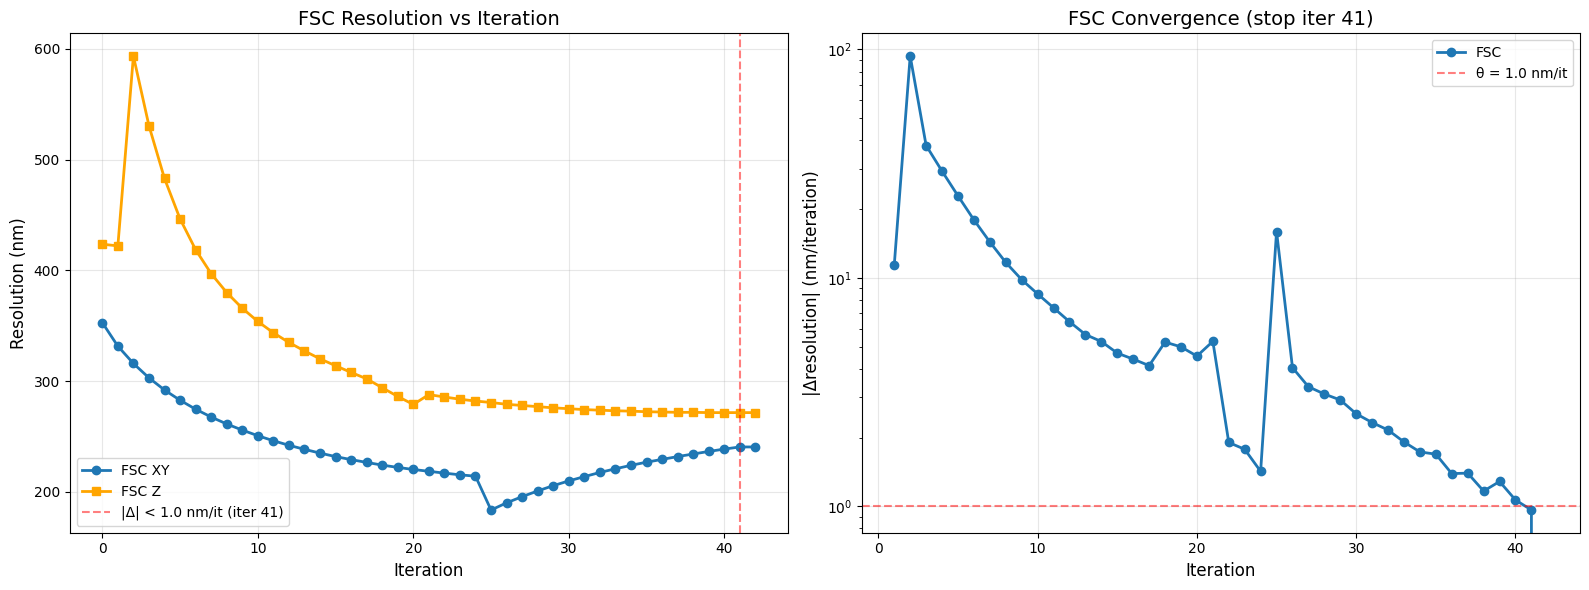


Summary:
  FSC converged at iteration 41 (|Δ| < 1.0 nm/it)
    XY: 352.8 → 240.5 nm
    Z:  423.6 → 271.5 nm
  DCR: ran 50 iterations (quantized, see note above)
    XY: 919.3 → 784.8 nm
    Z:  973.8 → 873.5 nm


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FSC: absolute resolution vs iteration
axes[0].plot(fsc_xy_resolutions, "o-", label="FSC XY", linewidth=2)
axes[0].plot(fsc_z_resolutions, "s-", color="orange", label="FSC Z", linewidth=2)
if fsc_thresh_iter > 0:
    axes[0].axvline(
        x=fsc_thresh_iter,
        color="r",
        linestyle="--",
        alpha=0.5,
        label=f"|Δ| < {fsc_metric_threshold} nm/it (iter {fsc_thresh_iter})",
    )
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Resolution (nm)", fontsize=12)
axes[0].set_title("FSC Resolution vs Iteration", fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# FSC convergence (|Δ|)
fsc_d_avg = (
    np.abs(np.diff(fsc_xy_resolutions)) + np.abs(np.diff(fsc_z_resolutions))
) / 2
axes[1].plot(
    np.arange(1, len(fsc_d_avg) + 1), fsc_d_avg, "o-", linewidth=2, label="FSC"
)
axes[1].axhline(
    y=fsc_metric_threshold,
    color="r",
    linestyle="--",
    alpha=0.5,
    label=f"θ = {fsc_metric_threshold} nm/it",
)
axes[1].set_xlabel("Iteration", fontsize=12)
axes[1].set_ylabel("|Δresolution| (nm/iteration)", fontsize=12)
axes[1].set_title(f"FSC Convergence (stop iter {fsc_thresh_iter})", fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(
    f"  FSC converged at iteration {fsc_thresh_iter} (|Δ| < {fsc_metric_threshold} nm/it)"
)
print(f"    XY: {fsc_xy_resolutions[0]:.1f} → {fsc_xy_resolutions[-1]:.1f} nm")
print(f"    Z:  {fsc_z_resolutions[0]:.1f} → {fsc_z_resolutions[-1]:.1f} nm")
print(f"  DCR: ran 50 iterations (quantized, see note above)")
print(f"    XY: {dcr_xy[0]:.1f} → {dcr_xy[-1]:.1f} nm")
print(f"    Z:  {dcr_z[0]:.1f} → {dcr_z[-1]:.1f} nm")

Both 3D FSC and 3D DCR provide directional resolution estimates:
- **XY resolution** improves more rapidly (lateral PSF is narrower)
- **Z resolution** improves more slowly (axial PSF is elongated)

The key differences:
- **FSC** uses checkerboard splitting which may introduce artifacts
- **DCR** is a single-image metric with no splitting required
- Both support `exclude_axis_angle` parameter for artifact exclusion

### Summary

This notebook demonstrated using resolution-based metrics to track 3D deconvolution progress:

| Metric | Dimensionality | Split Required | Directional |
|--------|----------------|----------------|-------------|
| PSNR | 3D (full volume) | No | No |
| SSIM | 3D (full volume) | No | No |
| FSC | 3D (full volume) | Yes (checkerboard) | Yes (XY/Z) |
| DCR | 3D (full volume) | No | Yes (XY/Z) |

For 3D volumes, **FSC** with `resample_isotropic=True` provides the most granular assessment by tracking both lateral (XY) and axial (Z) resolution improvements separately, following the approach of Koho et al. (2019, Fig. 3).

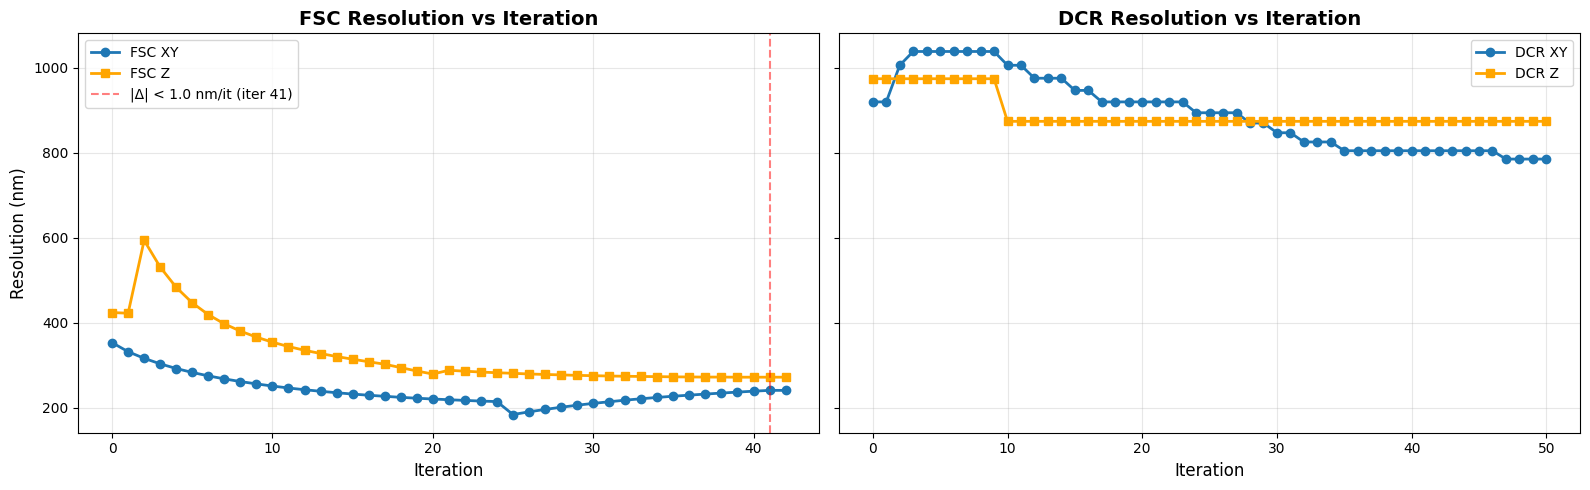


Convergence Summary:
  PSNR: reached 75 dB at iter 35
  SSIM: reached threshold at iter 37
  FSC:  iter 41 (3D, |Δ| < 1.0 nm/it)
  DCR:  XY 919 → 785 nm, Z 974 → 874 nm (quantized, see note)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# FSC: absolute resolution
axes[0].plot(fsc_xy_resolutions, "o-", label="FSC XY", linewidth=2)
axes[0].plot(fsc_z_resolutions, "s-", color="orange", label="FSC Z", linewidth=2)
if fsc_thresh_iter > 0:
    axes[0].axvline(
        x=fsc_thresh_iter,
        color="r",
        linestyle="--",
        alpha=0.5,
        label=f"|Δ| < {fsc_metric_threshold} nm/it (iter {fsc_thresh_iter})",
    )
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Resolution (nm)", fontsize=12)
axes[0].set_title("FSC Resolution vs Iteration", fontsize=14, fontweight="bold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# DCR: absolute resolution
axes[1].plot(dcr_xy_resolutions, "o-", label="DCR XY", linewidth=2)
axes[1].plot(dcr_z_resolutions, "s-", color="orange", label="DCR Z", linewidth=2)
axes[1].set_xlabel("Iteration", fontsize=12)
axes[1].set_title("DCR Resolution vs Iteration", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nConvergence Summary:")
print(f"  PSNR: reached 75 dB at iter {psnr_thresh_iter}")
print(f"  SSIM: reached threshold at iter {ssim_thresh_iter}")
print(f"  FSC:  iter {fsc_thresh_iter} (3D, |Δ| < {fsc_metric_threshold} nm/it)")
print(
    f"  DCR:  XY {dcr_xy[0]:.0f} → {dcr_xy[-1]:.0f} nm, Z {dcr_z[0]:.0f} → {dcr_z[-1]:.0f} nm (quantized, see note)"
)